# Analysis Notebook for Radio Star scans using BigDish

dsheen draft 2025-10-02, updated 2025-11-2

The following is a notebook for analysis of a scan of cygnus A* using map_grid.py. Over the course of the notebook we will import the log files, perform rfi-robust processing of the measured data, and use the result to estimate calibrator curves and the telescope sensitivity over the full protected band.

The results of this analysis for a known reference star can then be used to perform wideband calibration and generate temperature maps from scans of unknown sources using the data calibration and plotting techniques in this notebook.

it's probably better to use the current scan_radio_star.py and do fewer points with longer integration. Ideally one should also use calibrator stars that aren't adjacent other point sources (eg. not cygnus A*) 

## 1. Manual Generation of Radio Star Flux Curves

In [58]:
import os
import sys
import csv

import numpy as np
import scipy as sc
import astropy.units as u
import astropy.constants as const
import matplotlib.pyplot as plt

# Get the directory of the current directory
current_script_dir = os.getcwd()

# Construct the path to the top directory of the repo
repository_path = os.path.join(current_script_dir, '../..')
sys.path.append(repository_path)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


### Create a Nice Dictionary of Radio Stars we have Good Published Measurements for
use sources from

"An Accurate Flux Density Scale from 50MHz to 50GHz"

R. A. Perley and B. J. Butler National Radio Astronomy Observatory, P.O. Box O, Socorro, NM 87801, USA; RPerley@nrao.edu, BButler@nrao.edu

https://iopscience.iop.org/article/10.3847/1538-4365/aa6df9/pdf

so that we know we have good flux models for them. Only use relatively bright ones that are easy to find. Also save flux coefficents for them from table 6 so we can use this equation

$log(S)=a_0 +a_1log(f)+a_2[log(f)]^2 +a_3[log(f)]^3+ $.... for f in GHz and S in Jy

In [59]:
radio_stars = {}

radio_stars['3C48'] = {'coords':(24.42208192967, 33.15974455245), 
                       'coefficients' : np.array([1.3253, -0.7553,-0.1914,0.0498])}

radio_stars['FornaxA'] = {'coords':(50.6741208, -37.2082), 
                       'coefficients' : np.array([2.2175, -0.6606])}

radio_stars['3C123'] = {'coords':(69.26823064375, 29.67050498975), 
                       'coefficients' : np.array([1.8017, -0.7884, -0.1035, -0.0248, 0.0090])}

radio_stars['3C138'] = {'coords':(80.29119151075, 16.63945876275), 
                       'coefficients' : np.array([1.0088, -0.4981, -0.1552, -0.0102, 0.0223])}

radio_stars['PictorA'] = {'coords':(79.95717888494, -45.77884796187), 
                       'coefficients' : np.array([1.9380, -0.7470, -0.0739])}

radio_stars['TaurusA'] = {'coords':(83.6324, 22.0174), 
                       'coefficients' : np.array([2.9516, -0.2173, -0.0473, -0.0674]),
                    'beamwidth_correction' : 4.6}

radio_stars['3C147'] = {'coords':(85.65057457125, 49.852009364972), 
                       'coefficients' : np.array([1.4516, -0.6961, -0.2007, 0.0640, -0.0464, 0.0289])}

radio_stars['3C196'] = {'coords':(123.40023382088, 48.21740137945), 
                       'coefficients' : np.array([1.2872, -0.8530, -0.1534, -0.0200, 0.0201])}

radio_stars['HydraA'] = {'coords':(139.52361869175, -12.095501689528), 
                       'coefficients' : np.array([1.7795, -0.9176, -0.0843, -0.0139, 0.0295])}

radio_stars['VirgoA'] = {'coords':(187.70593076725, 12.391123246083), 
                       'coefficients' : np.array([2.4466, -0.8116, -0.0483]),
                         'beamwidth_correction' : 2.5}

radio_stars['3C286'] = {'coords':(202.78453479432, 30.50915558099), 
                       'coefficients' : np.array([1.2481, -0.4507, -0.1798, 0.0357])}

radio_stars['3C295'] = {'coords':(212.836, 52.2025), 
                       'coefficients' : np.array([1.4701, -0.7658, -0.2780, -0.0347, 0.0399])}

radio_stars['HerculesA'] = {'coords':(252.78328611990997, 4.99320753652), 
                       'coefficients' : np.array([1.8298, -1.0247, -0.0951])}

radio_stars['3C353'] = {'coords':(260.11736689063, -0.9796062372), 
                       'coefficients' : np.array([1.8627, -0.6938, -0.0998, -0.0732])}

radio_stars['3C380'] = {'coords':(277.38242072207, 48.74615560247), 
                       'coefficients' : np.array([1.2320, -0.7909, 0.0947, 0.0976, -0.1794, -0.1566])}

radio_stars['CygnusA'] = {'coords':(299.868152368208, 40.733915897917), 
                       'coefficients' : np.array([3.3498, -1.0022, -0.2246, 0.0227, 0.0425]),
                         'beamwidth_correction' : 2.5}

radio_stars['3C444'] = {'coords':(333.6073, -17.0267472), 
                       'coefficients' : np.array([1.1064, -1.0052, -0.0750, -0.0767])}

radio_stars['CassiopeiaA'] = {'coords':(350.8584, 58.8113), 
                        'coefficients' : np.array([3.3584, -0.7518, -0.0347, -0.0705]),
                        'beamwidth_correction' : 4.6}

radio_stars['Orion'] = {'coords':(83.8201, -5.3876), 
                       'coefficients' : np.array([2.705, -0.204]),
                       'beamwidth_correction' : 4.6}

In [60]:
def get_flux(star,f):
    '''
    star: str, name of star correcponding to dictinary entry key
    f: frequency or frequencies at which to compute flux
    '''
    
    a = radio_stars[star]['coefficients']
    logfreq = np.log10(f.to(u.GHz).value)
    
    
    logS = np.zeros_like(logfreq)
    for i in range(len(a)):
        logS += a[i]*np.power(logfreq,i)

    S = np.power(10,logS)*u.Jy
    return S

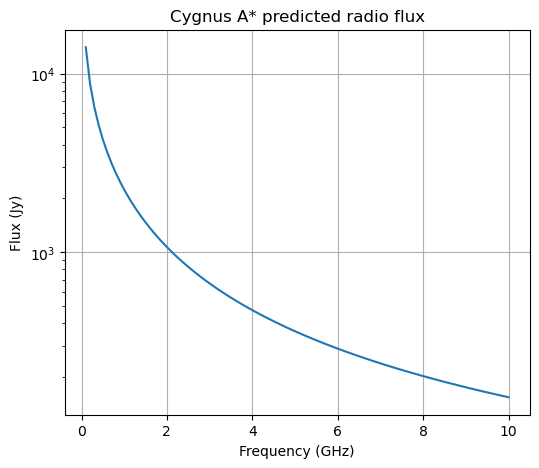

In [61]:
freqs = np.linspace(0.1,10,100)*u.GHz

plt.figure()
plt.semilogy(freqs,get_flux('CygnusA',freqs))
plt.ylabel("Flux (Jy)")
plt.xlabel("Frequency (GHz)")
plt.title("Cygnus A* predicted radio flux")
plt.grid()
plt.show()

### Antenna Parameters and Corrections

from the corrections in RECOMMENDATION ITU-R S.733-2

$\frac{G}{T} = \frac{8\pi k (r-1)}{\lambda^2 \Phi(f)}$

where $r = \frac{P_n + P_{st}}{P_n} = \frac{T_{sys} + T_{st}}{T_{sys}}$ and $\Phi(f)$ is the flux in $Wm^{-2}Hz^{-1}$ 


corrrection factor C2 is included for the angular extent of radio stars vs the beam width in equation 3

$(G/ T)_c = G/T + C1 + C2 + C3$

where C3 is only applicable to Cas A, C1 is a correction for atmospheric loss (which we shall ignore because I typically count that as part of G/T) and so C2 is the only thing that matters


$C2 \approx -10log_{10}\left[\frac{ABS \left( 1-e^{-\chi^2} \right)}{\chi^2}\right]$ in dB

where $\chi_{CygA} \approx \frac{2.5}{1.2012 \theta_{3dB} \times 60}$

and $\chi_{most other things} \approx \frac{4.6}{1.2012 \theta_{3dB} \times 60}$

In [62]:
def get_C2(star,Theta):
    '''
    star is name of star in dictionary
    Theta is half power beamwidth in degrees
    freq is frequency
    
    '''
    Chi = radio_stars[star]['beamwidth_correction']/(1.2012*Theta.to(u.degree).value*60)
    C2 = -10*np.log10(np.abs(1-np.exp(-Chi**2))/Chi**2)
    return C2

## 2. Import Log Data from Scan of Radio Star

Before we can do anything with the actual RF samples, we need to know where the telescope was pointed at what time and what the calibrator states were. for this we need to ingest and process the log file since we do not yet have a mechanism for adding this to the drf metadata during the recording.

the size of the files makes it impractical to keep any in the github so you will need to get your own. the DRF top directory and the logfile should be in the same folder

In [63]:
import os
import sys
import csv
from datetime import datetime, timezone
import numpy as np
import pandas as pd

### Get File Information

In [64]:
#observation directory path
#observation_directory = "/home/dsheen/temp_rf_data/cygnusA_2025-10-01_scan/"
#observation_directory = "/data/cygnus_2025-10-01"
observation_directory = "/data/dsheen/Bigdish_cygnusA_2025-10-01"

In [65]:
#grab logfile and drf file paths
files = os.listdir(observation_directory)

for file in files:
    if file.split('.')[-1] == 'log':
        logfile = file
        print(f"found log file {logfile}")
    else: #see if it's the drf directory
        try:
            subdirs = os.listdir(os.path.join(observation_directory, file))
            if 'LHCP' in subdirs or 'RHCP' in subdirs: #then this is probably the drf top directory
                drf_directory = file
                print(f"found drf directory {drf_directory}")
        except:
            print(f"skipping {file}. File does not appear to be digital_rf or logfile.")

found drf directory cygnusA_2025-10-01-test2
found log file 2025-10-02T00:56:29.283430Z_radec_299.87_299.87.log
skipping saved_spectra.pkl. File does not appear to be digital_rf or logfile.


### Read in the log data

In [66]:
scan_target_commands = []
scan_settling_times = []
scan_calibrator_transitions = []
telescope_positions = []

with open(os.path.join(observation_directory,logfile), 'r') as file:
    logdata = csv.reader(file)

    for row in logdata:
        #splitup by info type and save into python variables and lists

        #####################
        # header info
        #####################
        if row[0].strip() == "scan_coords":
            scan_coord_frame = row[1].strip() #coordinate system
        elif row[0].strip() == "scan_center":
            scan_center = np.array([float(row[i].strip()) for i in range(1,len(row))]) #scan center point
        elif row[0].strip() == "extents":
            extents = np.array([float(row[i].strip()) for i in range(1,len(row))]) #max range of scan from center point
        elif row[0].strip() == "steps":
            steps = np.array([float(row[i].strip()) for i in range(1,len(row))]) #step between points in both axes
        elif row[0].strip() == "num_points":
            num_points = int(row[1].strip()) #number of points in scan
        elif row[0].strip() == "integration_time":
            integration_time = float(row[1].strip()) #time in seconds to integrate after calibration period
        elif row[0].strip() == "cal_time":
            cal_time = float(row[1].strip()) #time for calibrator to be enabled on each channel

        ##########################
        # actual scan timing data
        ##########################
        elif row[0].strip() == "target_point":
            #append command time and coordinates
            scan_target_commands.append({'time': datetime.fromisoformat((row[1].strip()).replace('Z', '+00:00')), 
                                         'pos' : np.array([float(row[3].strip()),float(row[4].strip())])})

        elif row[0].strip() == "position":
            #telescope reported position time, coords, velocities
            telescope_positions.append({'time': datetime.fromisoformat((row[1].strip()).replace('Z', '+00:00')), 
                                        'pos' : np.array([float(row[2].strip()),float(row[3].strip())]), 
                                        'vel' : np.array([float(row[4].strip()),float(row[5].strip())])})
        elif row[0].strip() == "settled":
            #time when telescope has settled to target point
            scan_settling_times.append(datetime.fromisoformat((row[1].strip()).replace('Z', '+00:00')))
        elif row[0].strip() == "calibrator_state":
            #calibrator state timing info
            scan_calibrator_transitions.append({'time': datetime.fromisoformat((row[1].strip()).replace('Z', '+00:00')),
                                                'state': int(row[2].strip())})
        else: #something weird happened
            print(f"unrecognized line starting with {row[0].strip()}! Is file correct?")



print(f"scan contains {num_points} points centered about {scan_coord_frame} coordinates {scan_center}")
#telescope_positions = pd.DataFrame(telescope_positions)
#print(telescope_positions)

scan contains 225 points centered about radec coordinates [299.869  40.739]


### Manipulate this into a nicer format with a signle entry for each point telling us what segments of data are what

In [67]:
scan_points_info = []

#get an array of position timestamps for subsequent use
telescope_position_times = np.array([point['time'].timestamp() for point in telescope_positions])
telescope_position_coords = np.array([point['pos'] for point in telescope_positions])

def get_pointing_time_inices(bounds):
    tmin = bounds[0].timestamp()
    tmax = bounds[1].timestamp()
    imin = np.where(telescope_position_times>=tmin)[0][0]
    imax = np.where(telescope_position_times>=tmax)[0][0]
    return imin,imax

def get_mean_pointing_error(bounds, point):
    """return telescope mean error fromm target"""
    imin,imax = get_pointing_time_inices(bounds)
    positions = telescope_position_coords[imin:imax]
    errors = np.sqrt(np.sum(np.power(positions - point,2),axis=1))
    
    return np.mean(errors)


for i in range(num_points):
    scan_target_coords = scan_target_commands[i]["pos"]
    settling_time = scan_settling_times[i]
    cal_info = scan_calibrator_transitions[3*i:3*i+3]

    if i+1 ==num_points:
        end_time = telescope_positions[-1]["time"]
    else:
        end_time = scan_target_commands[i+1]["time"]

    cal_1_bounds = [cal_info[0]['time'], cal_info[1]['time']]
    cal_2_bounds = [cal_info[1]['time'], cal_info[2]['time']]
    cal_off_bounds = [cal_info[2]['time'], end_time]

    #get nominal pointing errors for these time ranges
    
    #cal1_timestamps 

    scan_points_info.append({'pos' : scan_target_coords,
                             'cal_1_bounds' : cal_1_bounds,
                             'cal_2_bounds' : cal_2_bounds,
                             'cal_off_bounds' : cal_off_bounds,
                             'cal_1_pos_error' : get_mean_pointing_error(cal_1_bounds, scan_target_coords),
                             'cal_2_pos_error' : get_mean_pointing_error(cal_2_bounds, scan_target_coords),
                             'cal_off_pos_error' : get_mean_pointing_error(cal_off_bounds, scan_target_coords),
                            })
    
scan_points_info = pd.DataFrame(scan_points_info)

print(scan_points_info.iloc[int(num_points/2)])

pos                                                  [299.869, 40.739]
cal_1_bounds         [2025-10-02 01:22:49+00:00, 2025-10-02 01:22:5...
cal_2_bounds         [2025-10-02 01:22:51+00:00, 2025-10-02 01:22:5...
cal_off_bounds       [2025-10-02 01:22:53+00:00, 2025-10-02 01:22:5...
cal_1_pos_error                                               0.066955
cal_2_pos_error                                               0.057766
cal_off_pos_error                                             0.041981
Name: 112, dtype: object


## 3. Digital RF data import and processing

pull in drf data, get metadata about frequency, sample rate etc. And process the data for each point into spectra for the different calibrator states 

In [68]:
import digital_rf as drf
import multiprocessing
from functools import partial

### Start by getting metadata

In [69]:
rf_data_path = os.path.join(observation_directory,drf_directory)
channels = ["RHCP","LHCP"]

In [70]:
dio = drf.DigitalRFReader(rf_data_path)
sr = dio.get_properties(channels[0])["samples_per_second"]
bounds = dio.get_bounds(channels[0])

dt_start = datetime.fromtimestamp(float(bounds[0] / sr), tz=timezone.utc,)
dt_stop = datetime.fromtimestamp(float(bounds[1] / sr), tz=timezone.utc)

metadata = dio.read_metadata(bounds[0],bounds[0]+1, channels[0])
metadata_key = list(metadata.keys())[0]
radio_metadata = metadata[metadata_key]
cf = radio_metadata['center_frequencies'][0]

print(f"Digital RF data has bounds {dt_start.isoformat()}, {dt_stop.isoformat()}")
print(f"sample rate {sr/1e6} MHz, center frequency {cf/1e6} MHz")

Digital RF data has bounds 2025-10-02T00:56:31+00:00, 2025-10-02T01:50:17+00:00
sample rate 25.0 MHz, center frequency 1413.5 MHz


### User Settings for spectrum slicing

In [71]:
num_frequency_points = 1024

slicelen = 0.1 #approx fft slice time in seconds for the fft computation to not be truly ridiculous 
#will be averaged anyway so just a computation efficincy thing
num_processes = 16

### Define a not completely insane multithreaded FFT processor

In [34]:
def calculate_welch_slice(channel, samples_per_slice, start_sample):
        '''
        Calculate the welch method spectrogram for the given data slice
        '''

        try:
            data = dio.read_vector(
                start_sample, samples_per_slice, channel, 0
            )
        except IOError:
            print(
                "IO Error for channel {0}:{1} start sample {2}".format(
                    channel,
                    start_sample,
                )
            )
            # handle data gaps better
            data = np.empty(samples_per_slice, np.complex64)
            data[:] = np.nan

        #actually handle the welch operation

        try:
            freq_axis, psd_data = sc.signal.welch(
                data,
                fs=float(sr),
                nperseg=num_frequency_points,
                detrend=False,
                scaling="density",
                return_onesided=False,
                average='median'
            )
        except Exception:
            traceback.print_exc(file=sys.stdout)

        #sti_psd_data = np.real(
        #    10.0 * np.log10(np.abs(sc.fft.fftshift(psd_data)) + 1e-20)
        #    )  # 1e-20 is added to prevent divide by zero issues with logarithm

        
        sti_psd_data = np.real(np.abs(sc.fft.fftshift(psd_data)))
        #how the time of the slice is defined is perhaps open to debate
        sti_time = (start_sample + samples_per_slice / 2) / sr
        #sti_time = (start_sample) / self.sample_rate

        return sti_psd_data, sc.fft.fftshift(freq_axis), sti_time

def process_data_spectrum(start_sample, end_sample, channel):
    samples_per_slice = int(sr*slicelen/num_frequency_points)*num_frequency_points
    start_samples = np.arange(start_sample,end_sample,samples_per_slice)

    pool = multiprocessing.Pool(processes=num_processes)
    welch_slice = partial(calculate_welch_slice, channel, samples_per_slice)

    outputs = pool.map(welch_slice, start_samples)

    pool.close()
    pool.join()

    sti_psd_data = outputs[0][0]
    freq_axis = outputs[0][1]

    for i in range(1,len(start_samples)):
        sti_psd_data += outputs[i][0]

    sti_psd_data = sti_psd_data/len(start_samples)
    return sti_psd_data, freq_axis

### Process spectra for each point

In [35]:
point_spectra = []

for i in range(num_points):
    print(f" working on point {i}")
    point_info = scan_points_info.iloc[i]
    
    cal_timing_margin = 0.01
    cal_1_sample_bounds = [int(point_info['cal_1_bounds'][0].timestamp()*sr + cal_timing_margin*sr),
                            int(point_info['cal_1_bounds'][1].timestamp()*sr - cal_timing_margin*sr)]
    cal_2_sample_bounds = [int(point_info['cal_2_bounds'][0].timestamp()*sr + cal_timing_margin*sr),
                            int(point_info['cal_2_bounds'][1].timestamp()*sr - cal_timing_margin*sr)]
    cal_off_sample_bounds = [int(point_info['cal_off_bounds'][0].timestamp()*sr + cal_timing_margin*sr),
                            int(point_info['cal_off_bounds'][1].timestamp()*sr - cal_timing_margin*sr)]
    
    # just hard code this because it makes building the arrays a little easier
    RHCP_cal_1_psd, freq_axis = process_data_spectrum(cal_1_sample_bounds[0], cal_1_sample_bounds[1], channels[0])
    RHCP_cal_2_psd, freq_axis = process_data_spectrum(cal_2_sample_bounds[0], cal_2_sample_bounds[1], channels[0])
    RHCP_cal_off_psd, freq_axis = process_data_spectrum(cal_off_sample_bounds[0], cal_off_sample_bounds[1],channels[0])

    LHCP_cal_1_psd, freq_axis = process_data_spectrum(cal_1_sample_bounds[0], cal_1_sample_bounds[1], channels[1])
    LHCP_cal_2_psd, freq_axis = process_data_spectrum(cal_2_sample_bounds[0], cal_2_sample_bounds[1], channels[1])
    LHCP_cal_off_psd, freq_axis = process_data_spectrum(cal_off_sample_bounds[0], cal_off_sample_bounds[1],channels[1])

    point_spectra.append({"frequencies" : freq_axis + cf,
                          "RHCP" : [RHCP_cal_off_psd, RHCP_cal_1_psd, RHCP_cal_2_psd],
                          "LHCP" : [LHCP_cal_off_psd, LHCP_cal_1_psd, LHCP_cal_2_psd]})

point_spectra = pd.DataFrame(point_spectra)

 working on point 0


KeyboardInterrupt: 

Process ForkPoolWorker-32:
Traceback (most recent call last):
  File "/home/dsheen/miniforge3/envs/interactive/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/dsheen/miniforge3/envs/interactive/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/home/dsheen/miniforge3/envs/interactive/lib/python3.12/multiprocessing/pool.py", line 125, in worker
    result = (True, func(*args, **kwds))
                    ^^^^^^^^^^^^^^^^^^^
  File "/home/dsheen/miniforge3/envs/interactive/lib/python3.12/multiprocessing/pool.py", line 48, in mapstar
    return list(map(*args))
           ^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_3851429/1835457515.py", line 24, in calculate_welch_slice
    freq_axis, psd_data = sc.signal.welch(
                          ^^^^^^^^^^^^^^^^
  File "/home/dsheen/miniforge3/envs/interactive/lib/python3.12/site-packages/scipy/signal/_spectral_py.py", line 652, in welc

In [ ]:
#save this so we don't always need to reprocess it if I close the notebook
point_spectra.to_pickle(os.path.join(observation_directory, "saved_spectra.pkl"))

### plot things just to check they're ok

note our gain actually seems to be rather wavy prior to correction

In [72]:
point_spectra = pd.read_pickle(os.path.join(observation_directory, "saved_spectra.pkl"))

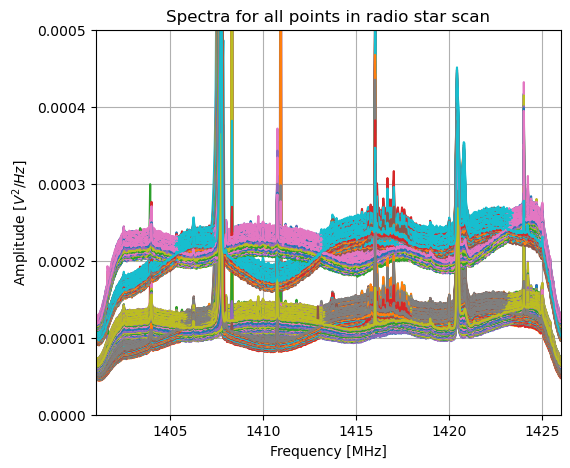

In [73]:
plt.figure()
for j in range(len(point_spectra)):
    for i in range(3):
        plt.plot(point_spectra['frequencies'][j]/1e6,point_spectra['RHCP'][j][i])
        plt.plot(point_spectra['frequencies'][j]/1e6,point_spectra['LHCP'][j][i])

plt.title("Spectra for all points in radio star scan")
plt.ylim([0,0.0005])
plt.ylabel(r"Amplitude $[V^2/Hz]$")
plt.xlim([point_spectra.iloc[0]['frequencies'][0]/1e6, point_spectra.iloc[0]['frequencies'][-1]/1e6])
plt.xlabel("Frequency [MHz]")
plt.grid()
plt.show()

## 4. Baseline flattening and initial calibrator shape estimation

estimate calibrator levels and flatten telescope baseline
note we do get the 3dB filter rolloff at the band edge like we should expect, and the calibrators are actualy extremely good at rejecting any of the rfi we see (almost none of it appears in the estimated calirator response)

In [74]:
### get calibrator deltas for all points and average
RHCP_cal = []
LHCP_cal = []

for i in range(num_points):

    RHCP_cal.append(point_spectra['RHCP'][i][1]- point_spectra['RHCP'][i][0])
    LHCP_cal.append(point_spectra['LHCP'][i][2]- point_spectra['LHCP'][i][0])

RHCP_cal = np.median(np.array(RHCP_cal),axis=0)
LHCP_cal = np.median(np.array(LHCP_cal),axis=0)

#RHCP_cal = np.mean(np.array(RHCP_cal),axis=0)
#LHCP_cal = np.mean(np.array(LHCP_cal),axis=0)

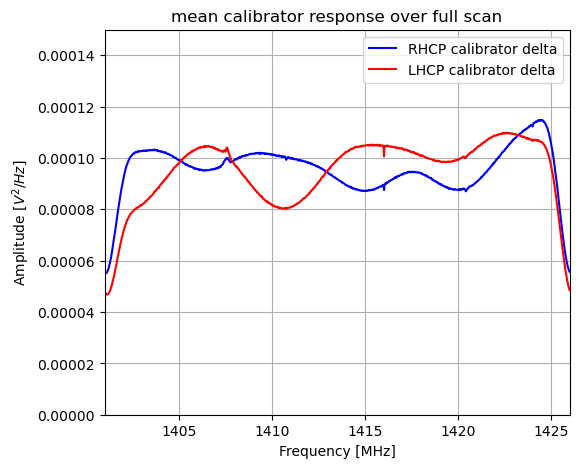

In [75]:
plt.figure()
#for j in range(len(point_spectra)):
    #for i in range(3):
plt.plot(point_spectra['frequencies'][0]/1e6,RHCP_cal,color='blue', label='RHCP calibrator delta')
plt.plot(point_spectra['frequencies'][0]/1e6,LHCP_cal,color='red', label='LHCP calibrator delta')

plt.title("mean calibrator response over full scan")
plt.ylim([0,0.00015])
plt.ylabel(r"Amplitude $[V^2/Hz]$")
plt.xlim([point_spectra.iloc[0]['frequencies'][0]/1e6, point_spectra.iloc[0]['frequencies'][-1]/1e6])
plt.xlabel("Frequency [MHz]")
plt.legend()
plt.grid()
plt.show()


### Normalize Calibrator Delta to unity across all frequencies and plot

Mostly this is to simplify later math since it's one fewer varying terms, but also this is a good check of whether the above ripple is from the calibrator or the gains after it. If it's purely gain ripple and the cal is relatively flat, then we should expect scaling by it to remove the ripple from both the cal signal and baseline, which is for the most part what we see.

In [76]:
normalized_spectra = []

for i in range(num_points):
    point = point_spectra.iloc[i]
    # just hard code this because it makes building the arrays a little easier
    RHCP_cal_1_psd = point['RHCP'][1]/RHCP_cal
    RHCP_cal_2_psd = point['RHCP'][2]/RHCP_cal
    RHCP_cal_off_psd = point['RHCP'][0]/RHCP_cal

    LHCP_cal_1_psd = point['LHCP'][1]/LHCP_cal
    LHCP_cal_2_psd = point['LHCP'][2]/LHCP_cal
    LHCP_cal_off_psd = point['LHCP'][0]/LHCP_cal

    normalized_spectra.append({"frequencies" : point['frequencies'],
                          "RHCP" : np.array([RHCP_cal_off_psd, RHCP_cal_1_psd, RHCP_cal_2_psd]),
                          "LHCP" : np.array([LHCP_cal_off_psd, LHCP_cal_1_psd, LHCP_cal_2_psd])})

normalized_spectra = pd.DataFrame(normalized_spectra)

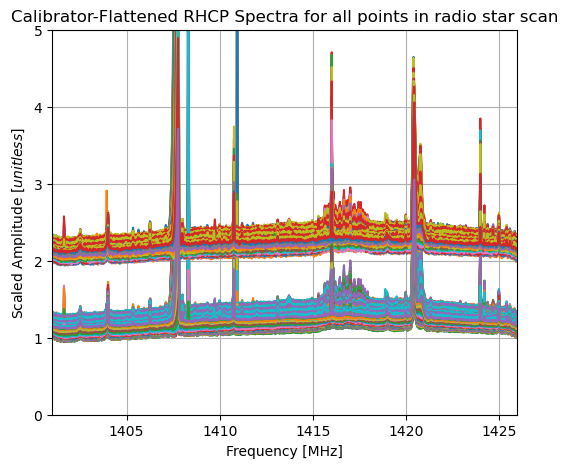

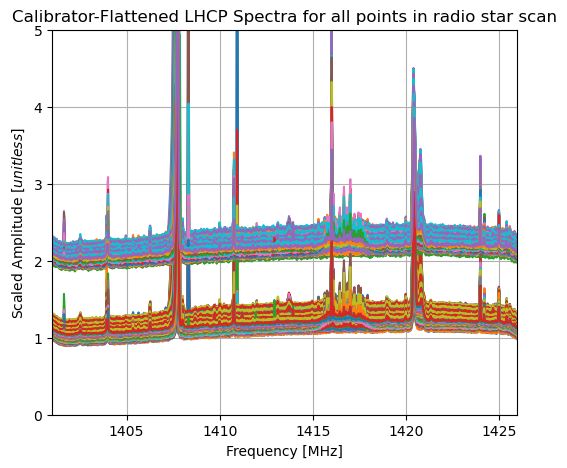

In [77]:
plt.figure()
for j in range(len(normalized_spectra)):
    for i in range(3):
        plt.plot(normalized_spectra['frequencies'][j]/1e6,normalized_spectra['RHCP'][j][i])
        #plt.plot(point_spectra['frequencies'][j]/1e6,point_spectra['LHCP'][j][i]/LHCP_cal)

plt.title("Calibrator-Flattened RHCP Spectra for all points in radio star scan")
plt.ylim([0,5])
plt.ylabel(r"Scaled Amplitude $[unitless]$")
plt.xlim([normalized_spectra.iloc[0]['frequencies'][0]/1e6, normalized_spectra.iloc[0]['frequencies'][-1]/1e6])
plt.xlabel("Frequency [MHz]")
plt.grid()
plt.show()

plt.figure()
for j in range(len(normalized_spectra)):
    for i in range(3):
        #plt.plot(point_spectra['frequencies'][j]/1e6,point_spectra['RHCP'][j][i]/RHCP_cal)
        plt.plot(normalized_spectra['frequencies'][j]/1e6,normalized_spectra['LHCP'][j][i])

plt.title("Calibrator-Flattened LHCP Spectra for all points in radio star scan")
plt.ylim([0,5])
plt.ylabel(r"Scaled Amplitude $[unitless]$")
plt.xlim([normalized_spectra.iloc[0]['frequencies'][0]/1e6, normalized_spectra.iloc[0]['frequencies'][-1]/1e6])
plt.xlabel("Frequency [MHz]")
plt.grid()
plt.show()

## 6. RFI Mask Generation

detect and exclude RFI that is significantly non-constant across the different measurement locations by looking at its variance

In [78]:
#for some reason the pandas to_numpy() method dooesn't work here so need to forcibly get these into numpy arrays
#in hidsight perhaps it was a poor choice of data structure 

RHCP_data = []
LHCP_data = []
positions = []

for i in range(num_points):
    point = normalized_spectra.iloc[i]
    # just hard code this because it makes building the arrays a little easier
    RHCP_data.append(point['RHCP'])
    LHCP_data.append(point['LHCP'])
    positions.append(scan_points_info['pos'][i])

RHCP_data = np.swapaxes(np.array(RHCP_data),0,1).reshape(3,num_points, num_frequency_points)
LHCP_data = np.swapaxes(np.array(LHCP_data),0,1).reshape(3,num_points, num_frequency_points)
positions = np.swapaxes(np.array(positions),0,1)
print(f" array shape: {np.shape(RHCP_data)}")

 array shape: (3, 225, 1024)


In [79]:
RHCP_flattened = RHCP_data.reshape(3*num_points, num_frequency_points)
LHCP_flattened = LHCP_data.reshape(3*num_points, num_frequency_points)

RHCP_flat_median = np.median(RHCP_flattened,axis=1)
LHCP_flat_median = np.median(LHCP_flattened,axis=1)

RHCP_med_removed = np.array([RHCP_flattened[i] - RHCP_flat_median[i] for i in range(num_points*3)])
LHCP_med_removed = np.array([LHCP_flattened[i] - LHCP_flat_median[i] for i in range(num_points*3)])

In [80]:
##get standard deviations

RHCP_std = np.std(RHCP_med_removed, axis=0)
LHCP_std = np.std(LHCP_med_removed, axis=0)

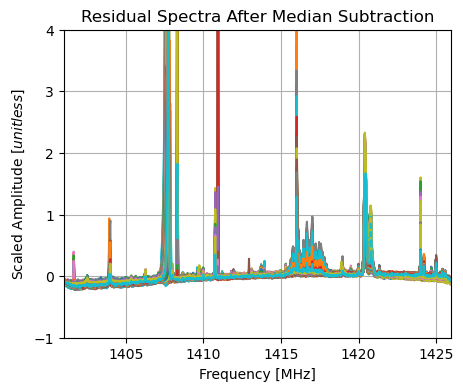

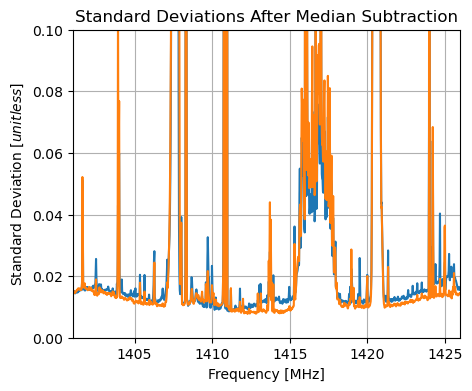

In [81]:
plt.rcParams['figure.figsize'] = [5, 4]

frequencies = normalized_spectra['frequencies'][0]/1e6

plt.figure()
for i in range(len(RHCP_med_removed)):
    plt.plot(frequencies,RHCP_med_removed[i])
    plt.plot(frequencies,LHCP_med_removed[i])

plt.title("Residual Spectra After Median Subtraction")
plt.ylim([-1,4])
plt.ylabel(r"Scaled Amplitude $[unitless]$")
plt.xlim([frequencies[0], frequencies[-1]])
plt.xlabel("Frequency [MHz]")
plt.grid()
plt.show()

plt.figure()

plt.plot(frequencies,RHCP_std)
plt.plot(frequencies,LHCP_std)

plt.title("Standard Deviations After Median Subtraction")
plt.ylim([0,0.1])
plt.ylabel(r"Standard Deviation $[unitless]$")
plt.xlim([frequencies[0], frequencies[-1]])
plt.xlabel("Frequency [MHz]")
plt.grid()
plt.show()

### throw out anything where the standard deviation is too high

in this case set threshold as more than 0.02

In [82]:
mean_std = (RHCP_std + LHCP_std)/2

good_indices = np.where(mean_std <= 0.02)
clean_frequencies = normalized_spectra['frequencies'][0][good_indices]
num_clean_frequencies = len(clean_frequencies)

In [83]:
RHCP_clean_data = []
LHCP_clean_data = []

for i in range(num_points):
    point = normalized_spectra.iloc[i]
    # just hard code this because it makes building the arrays a little easier
    RHCP_clean_data.append(point['RHCP'][:,good_indices])
    LHCP_clean_data.append(point['LHCP'][:,good_indices])


RHCP_clean_data = np.swapaxes(np.array(RHCP_clean_data),0,1).reshape(3,num_points, num_clean_frequencies)
LHCP_clean_data = np.swapaxes(np.array(LHCP_clean_data),0,1).reshape(3,num_points, num_clean_frequencies)

print(f" array shape: {np.shape(LHCP_clean_data)}")

 array shape: (3, 225, 808)


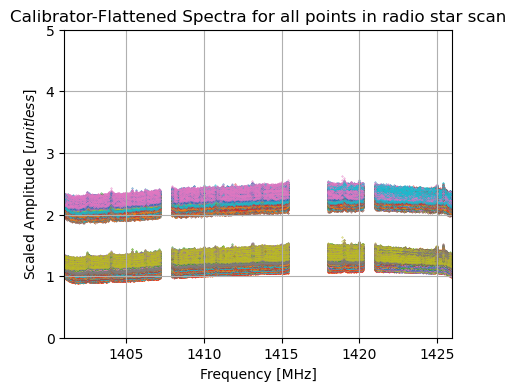

In [84]:
plt.figure()
for j in range(num_points):
    for i in range(3):
        plt.scatter(clean_frequencies/1e6,RHCP_clean_data[i][j],s=0.1)
        plt.scatter(clean_frequencies/1e6,LHCP_clean_data[i][j],s=0.1)
        #plt.plot(point_spectra['frequencies'][j]/1e6,point_spectra['LHCP'][j][i]/LHCP_cal)

plt.title("Calibrator-Flattened Spectra for all points in radio star scan")
plt.ylim([0,5])
plt.ylabel(r"Scaled Amplitude $[unitless]$")
plt.xlim([normalized_spectra.iloc[0]['frequencies'][0]/1e6, normalized_spectra.iloc[0]['frequencies'][-1]/1e6])
plt.xlabel("Frequency [MHz]")
plt.grid()
plt.show()


## 6. Uncalibrated Broadband Maps (use Median Estimator to remove remaining RFI initially for plots)

create arrays with dimensions (3,len1,len2,num_frequency_points) for each polarization to store all the data

RA stepped before dec in this scan

In [85]:
#get axes
#print(scan_points_info.iloc[0])
#print(scan_points_info.iloc[1])
ras = np.linspace(scan_center[0]-extents[0],scan_center[0]+extents[0], int(2*extents[0]/steps[0]+1))
print(f"ras: {ras}")
decs = np.linspace(scan_center[1]-extents[1],scan_center[1]+extents[1], int(2*extents[1]/steps[1]+1))
print(f"decs: {decs}")

ras: [294.619 295.369 296.119 296.869 297.619 298.369 299.119 299.869 300.619
 301.369 302.119 302.869 303.619 304.369 305.119]
decs: [35.489 36.239 36.989 37.739 38.489 39.239 39.989 40.739 41.489 42.239
 42.989 43.739 44.489 45.239 45.989]


In [86]:
#for some reason the pandas to_numpy() method dooesn't work here so need to forcibly get these into numpy arrays
#in hidsight perhaps it was a poor choice of data structure 

#RHCP_data = []
#LHCP_data = []

#for i in range(num_points):
#    point = normalized_spectra.iloc[i]
#    # just hard code this because it makes building the arrays a little easier
#    RHCP_data.append(point['RHCP'])
#    LHCP_data.append(point['LHCP'])

#RHCP_data = np.swapaxes(np.array(RHCP_data),0,1).reshape(3,len(decs), len(ras), num_frequency_points)
#LHCP_data = np.swapaxes(np.array(LHCP_data),0,1).reshape(3,len(decs), len(ras), num_frequency_points)
RHCP_data = RHCP_clean_data.reshape(3, len(decs), len(ras), num_clean_frequencies)
LHCP_data = LHCP_clean_data.reshape(3, len(decs), len(ras), num_clean_frequencies)
print(f" array shape: {np.shape(RHCP_data)}")

 array shape: (3, 15, 15, 808)


### Plot RCHP and LHCP data to verify this all lines up right

also run point by point calibration

In [87]:
RHCP_median = np.median(RHCP_data,axis=3)
LHCP_median = np.median(LHCP_data,axis=3)


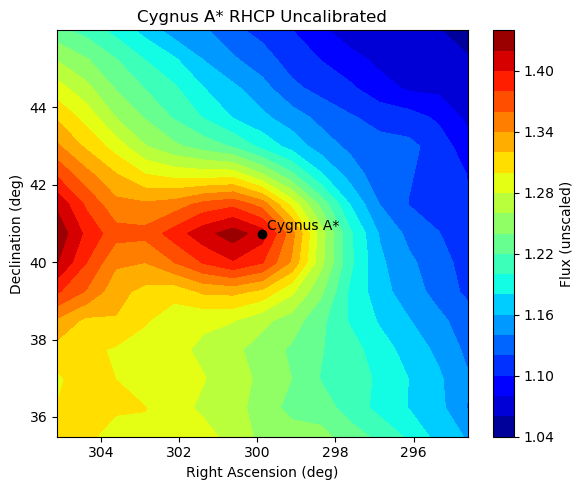

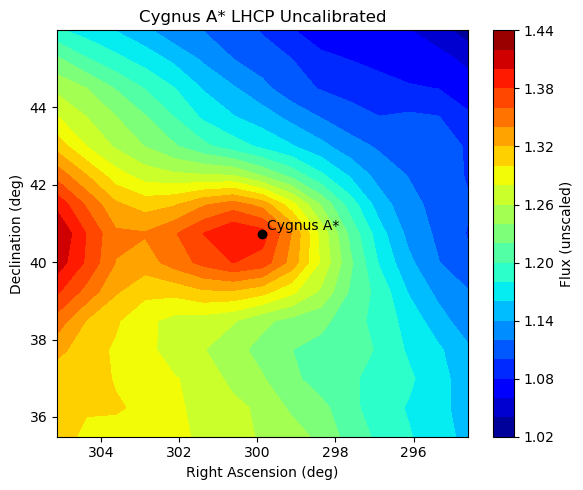

In [88]:
#test_data_point to make sure plotr allignment is right
#just make sure it lands in the spot I think it should
#print(scan_points_info.iloc[25]['pos'])
#RHCP_median[0,1,10] = 0
cygnus_a_jnow = (300.09111,40.8084)

plt.rcParams['figure.figsize'] = [6, 5]

plt.figure()
plt.contourf(ras,decs,RHCP_median[0],cmap='jet',levels=20)
#plt.imshow(RHCP_median[0],cmap='jet')
plt.plot(radio_stars['CygnusA']['coords'][0],radio_stars['CygnusA']['coords'][1],marker='o',label='Cygnus A*',color='black')
plt.annotate('Cygnus A*',radio_stars['CygnusA']['coords'],textcoords="offset points",xytext=(3,3))
plt.title('Cygnus A* RHCP Uncalibrated')
plt.xlabel('Right Ascension (deg)')
plt.ylabel('Declination (deg)')
plt.colorbar(label='Flux (unscaled)')
plt.gca().invert_xaxis()
plt.tight_layout()
#plt.savefig('plots/CygA_ch0_20241219_uncal_map.jpeg',dpi=200)
plt.show()

plt.figure()
plt.contourf(ras,decs,LHCP_median[0],cmap='jet',levels=20)
plt.plot(radio_stars['CygnusA']['coords'][0],radio_stars['CygnusA']['coords'][1],marker='o',label='Cygnus A*',color='black')
plt.annotate('Cygnus A*',radio_stars['CygnusA']['coords'],textcoords="offset points",xytext=(3,3))
plt.title('Cygnus A* LHCP Uncalibrated')
plt.xlabel('Right Ascension (deg)')
plt.ylabel('Declination (deg)')
plt.colorbar(label='Flux (unscaled)')
plt.gca().invert_xaxis()
plt.tight_layout()
#plt.savefig('plots/CygA_ch0_20241219_uncal_map.jpeg',dpi=200)
plt.show()

### plot calibrator response 

In [89]:
RHCP_median = np.median(RHCP_data,axis=3)
LHCP_median = np.median(LHCP_data,axis=3)

RHCP_CAL_median = np.median(RHCP_data[1]-RHCP_data[0], axis=2)
LHCP_CAL_median = np.median(LHCP_data[2]-LHCP_data[0], axis=2)
#LHCP_median = np.median(LHCP_data/(LHCP_data[2]-LHCP_data[0]), axis=3)

#RHCP_median = np.median(RHCP_data,axis=3)/np.median(RHCP_data[1]-RHCP_data[0], axis=2)
#LHCP_median = np.median(LHCP_data,axis=3)/np.median(LHCP_data[2]-LHCP_data[0], axis=2)

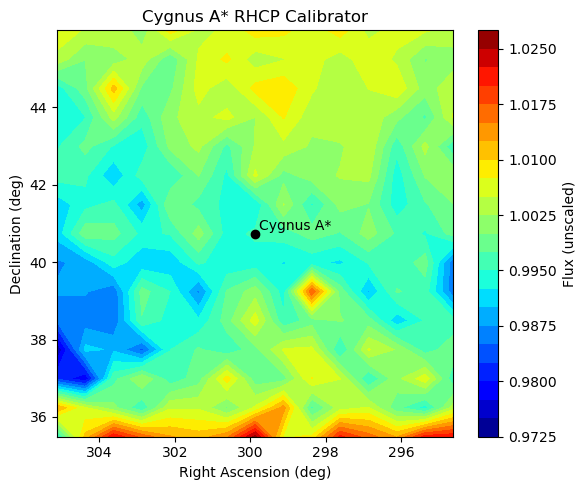

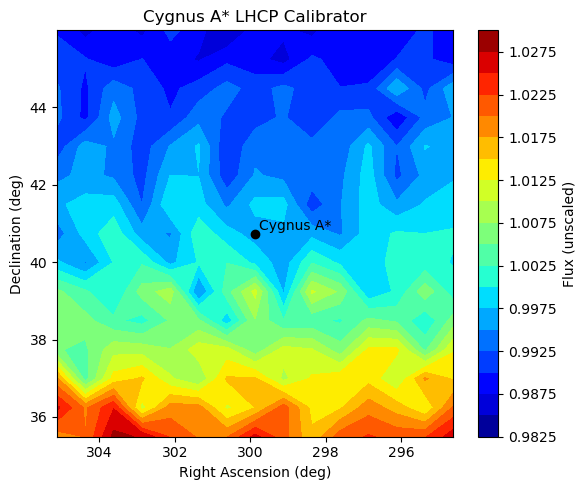

In [90]:
plt.rcParams['figure.figsize'] = [6, 5]

plt.figure()
plt.contourf(ras,decs,RHCP_CAL_median,cmap='jet',levels=20)
#plt.imshow(RHCP_median[0],cmap='jet')
plt.plot(radio_stars['CygnusA']['coords'][0],radio_stars['CygnusA']['coords'][1],marker='o',label='Cygnus A*',color='black')
plt.annotate('Cygnus A*',radio_stars['CygnusA']['coords'],textcoords="offset points",xytext=(3,3))
plt.title('Cygnus A* RHCP Calibrator')
plt.xlabel('Right Ascension (deg)')
plt.ylabel('Declination (deg)')
plt.colorbar(label='Flux (unscaled)')
plt.gca().invert_xaxis()
plt.tight_layout()
#plt.savefig('plots/CygA_ch0_20241219_uncal_map.jpeg',dpi=200)
plt.show()

plt.figure()
plt.contourf(ras,decs,LHCP_CAL_median,cmap='jet',levels=20)
plt.plot(radio_stars['CygnusA']['coords'][0],radio_stars['CygnusA']['coords'][1],marker='o',label='Cygnus A*',color='black')
plt.annotate('Cygnus A*',radio_stars['CygnusA']['coords'],textcoords="offset points",xytext=(3,3))
plt.title('Cygnus A* LHCP Calibrator')
plt.xlabel('Right Ascension (deg)')
plt.ylabel('Declination (deg)')
plt.colorbar(label='Flux (unscaled)')
plt.gca().invert_xaxis()
plt.tight_layout()
#plt.savefig('plots/CygA_ch0_20241219_uncal_map.jpeg',dpi=200)
plt.show()

## 6. Fit Cygnus A* Response to telescope beam profile

use a gaussian model for the telescope beam here since it's good enough

In [91]:
import scipy.optimize as opt
from antenna_data.beam_pattern import BeamPattern
Beam_Response_Estimator = BeamPattern(pattern_file_path=os.path.join(repository_path,'antenna_data/Real_feed_long_spars_and_feed_frame_dense.cut'))

total directivity =  36.63595475628274
phistep = 5.0
thetastep = 0.25


### Profile Definition for source we are looking at (Specific to Cygnus A in this case)

In [92]:
def gaussian(x,y, var):
    return np.exp(-(x**2 + y**2)/(2*var))

def Beam_Response(x,y):
    """ 
    return normalized beam profile model for a source at a given x/y angle offset using the antenna model from TICRA
    """

    thetas, phis = Beam_Response_Estimator.cartesian_angle_to_theta_phi(x,y)
    linear_beam_response = np.squeeze(Beam_Response_Estimator.get_linear_total_directivities(thetas,phis,normalized=True))
    return linear_beam_response

def CygA_Beam_Response_Estimate(xy, xcyg, ycyg, xh, yh, acyg, ah, xslope, yslope, baseoffset):
    """
    this is fiddly because really need a second gaussian for the other source nearby
    *other source clearly somewhere near (305,41) need to actually figure this out exactly at some point
    
    x,y coordinates
    xcyg, ycyg centerpoint of gaussian on cygnus
    xh, yh center of gaussian on HII region
    acyg = amplitude of cygnus gaussian,
    ah = amplitude of HII gaussian
    xslope, yslope slope of background at gaussian location
    baseoffset background level at gaussian location
    """

    #beam params
    #beamwidth = 2.90 #degrees
    #var =(beamwidth/2)**2 /(2* np.log(2))

    x, y = xy

    #fix coord frame distortion
    x_source = (x-xcyg)*np.cos(np.deg2rad(y)) 
    y_source = y-ycyg

    x_other = (x-xh)*np.cos(np.deg2rad(y)) 
    y_other = y-yh

    #background level
    background = baseoffset + xslope * x_source + yslope*y_source

    #cygnus gaussian
    cyg = acyg* Beam_Response(x_source, y_source)
    #other gaussian
    h = ah* Beam_Response(x_other, y_other)

    #total
    response = cyg + h + background

    return response.ravel()

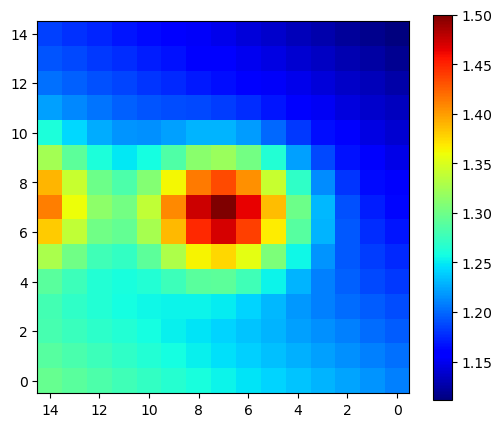

In [93]:
# xcyg, ycyg, xh, yh, acyg, ah, xslope, yslope, baseoffset
initial_guess = (radio_stars['CygnusA']['coords'][0], radio_stars['CygnusA']['coords'][1], 306, 41, 0.3, 0.5, 0.05, -0.01, 1.2)

x = ras
y = decs
x, y = np.meshgrid(x, y)

test_estimate = CygA_Beam_Response_Estimate((x,y), radio_stars['CygnusA']['coords'][0], radio_stars['CygnusA']['coords'][1], 306, 41, 0.3, 0.2, 0.01, -0.01, 1.2)

plt.figure()
plt.imshow(test_estimate.reshape(np.shape(x)),cmap='jet',origin='lower')
plt.gca().invert_xaxis()
plt.colorbar()

### try to fit beam plot to the actual data and get back the amplitude

do this on individually levelled cal data points since it seemse there's a pattern that supresses cygA a little in the uncalibrated data

In [ ]:
x = ras
y = decs
x, y = np.meshgrid(x, y)

initial_guess = (radio_stars['CygnusA']['coords'][0], radio_stars['CygnusA']['coords'][1], 306, 40.5, 0.2, 0.3, 0.01, -0.01, 1)

rpopt, rpcov = opt.curve_fit(CygA_Beam_Response_Estimate, (x,y), (RHCP_median[0]/RHCP_CAL_median).reshape(-1,), p0 = initial_guess)
lpopt, lpcov = opt.curve_fit(CygA_Beam_Response_Estimate, (x,y), (LHCP_median[0]/LHCP_CAL_median).reshape(-1,), p0 = initial_guess)

In [172]:
##background at cygnus includes the other annoying source so we do need to include it in the Y factor
nearby_source_y_offsets = np.array([rpopt[3],lpopt[3]]) - radio_stars['CygnusA']['coords'][1]
nearby_source_x_offsets = (np.array([rpopt[2],lpopt[2]]) - radio_stars['CygnusA']['coords'][0])*np.cos(np.deg2rad(np.array([rpopt[3],lpopt[3]])))

nearby_source_contribs = np.array([rpopt[5],lpopt[5]]) * Beam_Response(nearby_source_x_offsets, nearby_source_y_offsets)

r_cygA_estimates = np.array([(rpopt[4]+rpopt[8]+nearby_source_contribs[0])/(rpopt[8]+nearby_source_contribs[0]),
                             (lpopt[4]+lpopt[8]+nearby_source_contribs[1])/(lpopt[8]+nearby_source_contribs[1])]) #on/off source ratios
background_level_estimates = np.array([rpopt[8]+nearby_source_contribs[0],lpopt[8]+nearby_source_contribs[1]])

#print(f"Cyg A amplitude estimates {rpopt[4],lpopt[4]}")
#print(f"background_level estimates {rpopt[8],lpopt[8]}")

print(f"Cygnus A coords RHCP Estimate: RA = {rpopt[0]}, Dec = {rpopt[1]}")
print(f"Cygnus A coords LHCP Estimate: RA = {lpopt[0]}, Dec = {lpopt[1]}")

print(f"CygnusA peak flux relative to calibrators: RHCP = {rpopt[4]}, LHCP = {lpopt[4]}")
print(f"other source peak flux relative to calibrators: RHCP = {rpopt[5]}, LHCP = {lpopt[5]}")
print(f"Background flux relative to calibrators: RHCP = {rpopt[8]}, LHCP = {lpopt[8]}")
print(f"RHCP Background flux slopes to calibrators: dra = {rpopt[6]}, ddec = {rpopt[7]}")
print(f"LHCP Background flux slopes to calibrators: dra = {lpopt[6]}, ddec = {lpopt[7]}")

Cygnus A coords RHCP Estimate: RA = 300.42494331530617, Dec = 40.718527073850304
Cygnus A coords LHCP Estimate: RA = 300.16732551331023, Dec = 40.67198742650271
CygnusA peak flux relative to calibrators: RHCP = 0.2255391543629013, LHCP = 0.21314997286929138
other source peak flux relative to calibrators: RHCP = 0.1751844118558375, LHCP = 0.1693305583737334
Background flux relative to calibrators: RHCP = 1.2041270727104794, LHCP = 1.188857662107265
RHCP Background flux slopes to calibrators: dra = 0.023528597916272178, ddec = -0.011899093204935157
LHCP Background flux slopes to calibrators: dra = 0.020538426062234345, ddec = -0.009704620414460671


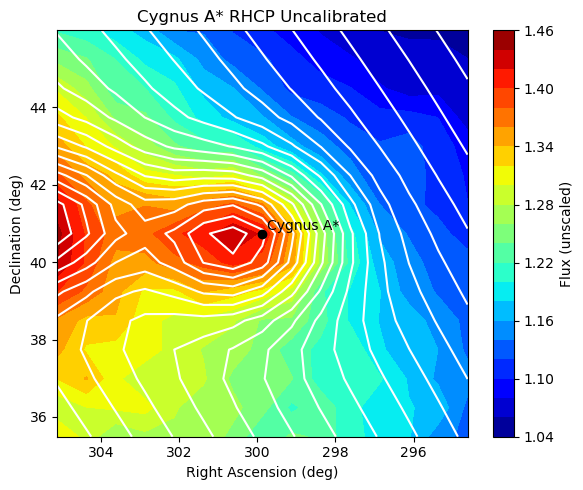

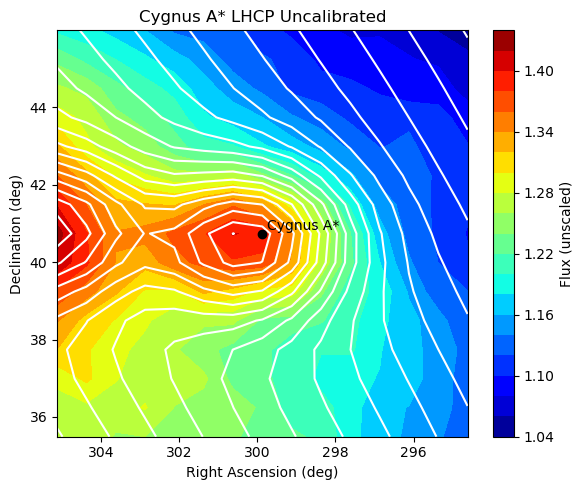

In [173]:
rdata_fitted = CygA_Beam_Response_Estimate((x, y), *rpopt)
ldata_fitted = CygA_Beam_Response_Estimate((x, y), *lpopt)

plt.figure()
plt.contourf(ras,decs,(RHCP_median[0]/RHCP_CAL_median),cmap='jet',levels=20)
plt.colorbar(label='Flux (unscaled)')
plt.contour(ras, decs, rdata_fitted.reshape(len(ras), len(decs)), 20, colors='w')
plt.plot(radio_stars['CygnusA']['coords'][0],radio_stars['CygnusA']['coords'][1],marker='o',label='Cygnus A*',color='black')
plt.annotate('Cygnus A*',radio_stars['CygnusA']['coords'],textcoords="offset points",xytext=(3,3))
plt.title('Cygnus A* RHCP Uncalibrated')
plt.xlabel('Right Ascension (deg)')
plt.ylabel('Declination (deg)')
plt.gca().invert_xaxis()
plt.tight_layout()
#plt.savefig('plots/CygA_ch0_20241219_uncal_map.jpeg',dpi=200)
plt.show()

plt.figure()
plt.contourf(ras,decs,(LHCP_median[0]/LHCP_CAL_median),cmap='jet',levels=20)
plt.colorbar(label='Flux (unscaled)')
plt.contour(ras, decs, ldata_fitted.reshape(len(ras), len(decs)), 20, colors='w')
plt.plot(radio_stars['CygnusA']['coords'][0],radio_stars['CygnusA']['coords'][1],marker='o',label='Cygnus A*',color='black')
plt.annotate('Cygnus A*',radio_stars['CygnusA']['coords'],textcoords="offset points",xytext=(3,3))
plt.title('Cygnus A* LHCP Uncalibrated')
plt.xlabel('Right Ascension (deg)')
plt.ylabel('Declination (deg)')
plt.gca().invert_xaxis()
plt.tight_layout()
#plt.savefig('plots/CygA_ch0_20241219_uncal_map.jpeg',dpi=200)
plt.show()

## 7. Full Band Aggregate Performance Initial Estimates

get the mean flux within the measurement bandwidth and use that and the Y factor to get an initial SEFD estimate, also estimate calibrator levels in Jy independent of baseline, conversion factor between kelvin and Jy, etc.
then see if we can do flux curve to do fine correction across the full band (probably not since I don't know the curve for the neighboing source)

### start by just retrieving the Y factors we got from the data

In [163]:
print(f"CygA RHCP Y Factor {r_cygA_estimates[0]}")
print(f"CygA LHCP Y Factor {r_cygA_estimates[1]}")

CygA RHCP Y Factor 1.1872338671274771
CygA LHCP Y Factor 1.1792069648763608


### Plot cygnus flux over the protected band and compute mean flux relevant to above measurement

note this is essentially flat across the band. Varies by less than 2%

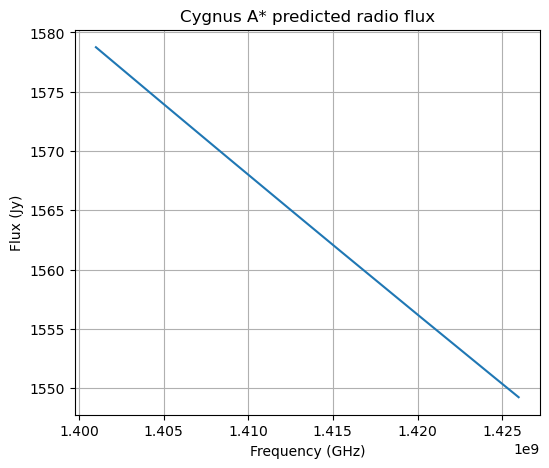

Average CygnusA flux across observation is 1564.4500935625983 Jy


In [164]:
frequencies = (normalized_spectra.iloc[0]['frequencies']*u.Hz).to(u.GHz)


plt.figure()
plt.plot(clean_frequencies,get_flux('CygnusA',(clean_frequencies*u.Hz).to(u.GHz)))
plt.ylabel("Flux (Jy)")
plt.xlabel("Frequency (GHz)")
plt.title("Cygnus A* predicted radio flux")
plt.grid()
plt.show()

mean_flux = np.mean(get_flux('CygnusA',(clean_frequencies*u.Hz).to(u.GHz)))
med_flux = np.median(get_flux('CygnusA',(clean_frequencies*u.Hz).to(u.GHz)))
print(f"Average CygnusA flux across observation is {mean_flux}")

## Calibrator Flux Estimate

We previously normalized the data for the calibrator level, such that the scaling in our data is calibrator_level = 1. this means knowing the source flux we can directly solve for the calibrator average level across the band.

In [165]:
source_fit_levels = np.array([rpopt[4], lpopt[4]])
cal_levels_estimate = med_flux / source_fit_levels
print(f"RHCP cal Estimate: {cal_levels_estimate[0]}")
print(f"LHCP cal Estimate: {cal_levels_estimate[1]}")

RHCP cal Estimate: 6940.095130235436 Jy
LHCP cal Estimate: 7343.482928009783 Jy


## Temperature Estimates

assuming antenna gain is in fact about net 36.2 dBi then we can compute the conversion between temp in kelvin and flux in Jy just by knowing the apperture efficiency and area

interestingly these are actually a bit low compared to the levels we have used up to the current time, this may imply we've been slightly overestimating the system noise, and suggests the possibility that the slightly higher gain from ticr (36.65 dBi as opposed to 36.2 from HFSS may actually be plausible

In [166]:
freq = 1.420*u.GHz
wavelength = (const.c/freq).decompose()
d_bigdish=5.4864*u.m
A_bigdish = np.pi * (d_bigdish/2)**2
#G_bigdish = 10**3.62 #original gain from old HFSS sims
G_bigdish = 10**3.65 #slightly higher possible gain allowing for ticra estimated antenna directivity
G_ideal_bigdish = (4 * np.pi * A_bigdish / (wavelength**2)).decompose()

Z_ref = 50 * u.ohm #system reference impedance

## apperture efficiency
eta_bigdish = G_bigdish/G_ideal_bigdish

#conversion factor betweek Jy and kelvin

#T_1jy = (1 * u.Jy * A_bigdish * eta_bigdish  / (4*const.k_B)).decompose()
K_per_Jy = (A_bigdish * eta_bigdish  / (4*const.k_B)).to(u.K/u.Jy)
print(K_per_Jy)

0.0028688746900911374 K / Jy


In [167]:
# the factor of 2 arises here because of the polarization loss in the source observation
cal_temps_estimate = cal_levels_estimate * 2 * K_per_Jy
print(f"RHCP cal Estimate: {cal_temps_estimate[0]}")
print(f"LHCP cal Estimate: {cal_temps_estimate[1]}")

RHCP cal Estimate: 39.820526531914396 K
LHCP cal Estimate: 42.13506461856725 K


## SEFD and G/T at Cygnus A*

SEFD = flux/ (Y-1)

it's somewhat important to note that this uses the estimated background at cygnusA

In [168]:
SEFD = mean_flux/(r_cygA_estimates-1)
wavelength = const.c/np.mean(frequencies)
Theta3dB = 2.9*u.degree

G_over_T = ((r_cygA_estimates-1) * 8 * np.pi * const.k_B / (mean_flux*wavelength**2)).decompose() 
C2 = get_C2('CygnusA',Theta3dB)

G_over_T_dB = 10*np.log10(G_over_T.value)+C2

print(f"SEFD of the RHCP Channel over the full bandwidth is {SEFD[0]}")
print(f"G/T of the RHCP Channel over the full bandwidth is {G_over_T_dB[0]} dB/K")
print(f"SEFD of the LHCP Channel over the full bandwidth is {SEFD[1]}")
print(f"G/T of the LHCP Channel over the full bandwidth is {G_over_T_dB[1]} dB/K")

SEFD of the RHCP Channel over the full bandwidth is 8355.593555611662 Jy
G/T of the RHCP Channel over the full bandwidth is 19.653196217481465 dB/K
SEFD of the LHCP Channel over the full bandwidth is 8729.850955524806 Jy
G/T of the LHCP Channel over the full bandwidth is 19.462900989421353 dB/K


### check system temperatures based on what we believe gain to be

if our modeled gain for the telescope is correct. Based on G/T we can calibrate the baseline temperature from the G/T ratio just by recovering the temperature in dBK

ideally this would also be a useful crosscheck because calculating this from G/T and from the modelled background level and calibrator temps should give the same values if our gain estimate is accurate, but it appears we accrue enough of an error somewhere that they can't be made to agree perfectly

In [171]:
T_sys_cal = cal_temps_estimate * np.array([rpopt[8], lpopt[8]])


print(f"Estimated Tsys at Cyg A background from calibrators, RHCP: {T_sys_cal[0]}, LHCP: {T_sys_cal[1]}") 

T_dB = 10*np.log10(G_bigdish) - G_over_T_dB
T_sys = 10**(T_dB/10)*u.K

print(f"Estimated Tsys at Cyg A background from SEFD, RHCP: {T_sys[0]}, LHCP: {T_sys[1]}") 

Estimated Tsys at Cyg A background from calibrators, RHCP: 47.948974046664055 K, LHCP: 50.0925944151684 K
Estimated Tsys at Cyg A background from SEFD, RHCP: 48.38161689824931 K, LHCP: 50.54868953329528 K


### Flux Scaling for Plotting

Use the fitted amplitude of the star and SEFD to get to the actual scaling to levels in Jy. Because we've normalized over the calibrator we can actually get these directly (since calibrator level is 1 when unscaled in the data we applied the fit to 

In [181]:
RHCP_flux_scaling = med_flux/rpopt[4] # also = cal_levels_estimate[0] 
LHCP_flux_scaling = med_flux/lpopt[4] # also = cal_levels_estimate[1] 

print(f"RHCP cal flux is {RHCP_flux_scaling}")
print(f"LHCP cal flux is {LHCP_flux_scaling}")

RHCP cal flux is 6940.095130235436 Jy
LHCP cal flux is 7343.482928009783 Jy


the same trick means our nominal estimate of the calibrator temperature is 1/background * Tsys, which we note gives a slightly different (presumably less accurate) result than before

In [182]:
alternate_cal_estimates = T_sys/background_level_estimates
print(f"RHCP cal temperature is {cal_estimates[0]}")
print(f"LHCP cal temperature is {cal_estimates[1]}")

RHCP cal temperature is 40.164543736665586 K
LHCP cal temperature is 42.499077564013156 K


## 8. Plot Calibrated Temperature Map

if we already know the calibrator temperatures in Jy, then we can just get to a map like this directly for any point in the sky without using a reference star.

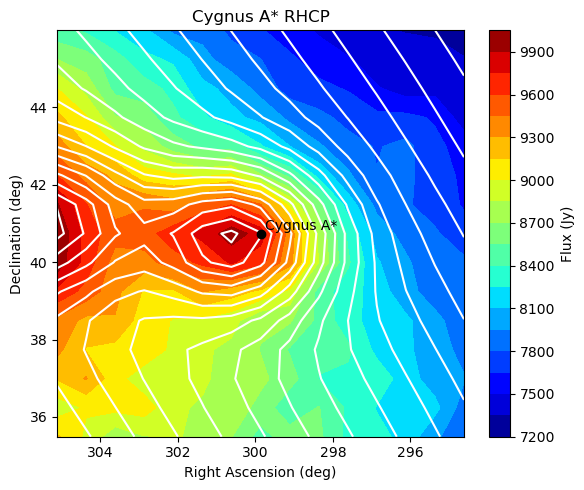

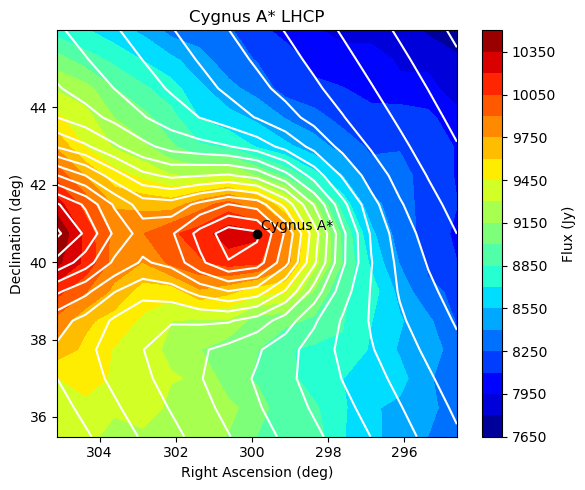

In [183]:
plt.figure()
plt.contourf(ras,decs,(RHCP_median[0]/RHCP_CAL_median)*RHCP_flux_scaling.value,cmap='jet',levels=20)
plt.colorbar(label='Flux (Jy)')
plt.contour(ras, decs, rdata_fitted.reshape(len(ras), len(decs))*RHCP_flux_scaling.value, 20, colors='w')
plt.plot(radio_stars['CygnusA']['coords'][0],radio_stars['CygnusA']['coords'][1],marker='o',label='Cygnus A*',color='black')
plt.annotate('Cygnus A*',radio_stars['CygnusA']['coords'],textcoords="offset points",xytext=(3,3))
plt.title('Cygnus A* RHCP')
plt.xlabel('Right Ascension (deg)')
plt.ylabel('Declination (deg)')
plt.gca().invert_xaxis()
plt.tight_layout()
#plt.savefig('plots/CygA_ch0_20241219_uncal_map.jpeg',dpi=200)
plt.show()

plt.figure()
plt.contourf(ras,decs,(LHCP_median[0]/LHCP_CAL_median)*LHCP_flux_scaling.value,cmap='jet',levels=20)
plt.colorbar(label='Flux (Jy)')
plt.contour(ras, decs, ldata_fitted.reshape(len(ras), len(decs))*LHCP_flux_scaling.value, 20, colors='w')
plt.plot(radio_stars['CygnusA']['coords'][0],radio_stars['CygnusA']['coords'][1],marker='o',label='Cygnus A*',color='black')
plt.annotate('Cygnus A*',radio_stars['CygnusA']['coords'],textcoords="offset points",xytext=(3,3))
plt.title('Cygnus A* LHCP')
plt.xlabel('Right Ascension (deg)')
plt.ylabel('Declination (deg)')
plt.gca().invert_xaxis()
plt.tight_layout()
#plt.savefig('plots/CygA_ch0_20241219_uncal_map.jpeg',dpi=200)
plt.show()